### 2sfca 계산 흐름 작성해보자.

공급은 병원, 수요는 인구일때 특정 지역의 병원 접근성을 평가하는 과정이다.

크게 2단계로 나뉜다. 

1단계: 병원(병상수) 를 인구수(해당 병원 서비스 이용 가능한 지역의)로 나눈값을 구한다. 즉 공급/수요 비를 구한다.
2단계: 각 지역(여기서는 동 단위로 구분)에서 접근가능한 병원들의 위에서 구한 공급/수요 비의 합계를 구한다. 이는 각 지역의 병원 접근성 정도를 나타내는 상대적 척도 값이 된다.

보다 구체적으로 해보자

### 데이터 준비
필요 데이터
1. 병원 데이터
2. 인구 수 데이터
3. 임계거리 설정, dist = 5000m
4. 도로 기반 거리를 반영할거다(유클리드는 부정확하니), 즉 osmnx로 부터 분석 지역의 그래프 데이터 불러오자.

In [3]:
import geopandas as gpd
import pandas as pd
import osmnx as ox
import time
import numpy as np
from tqdm import tqdm, trange
from shapely.geometry import Point, MultiPoint
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings("ignore")

In [4]:
hospitals = gpd.read_file('./lab_13_1_data/hospitals.shp')
hospitals = hospitals.to_crs("epsg:4326")
dongs = gpd.read_file('./lab_13_1_data/dongs.shp')
dongs = dongs.to_crs("epsg:4326")

dist = 5000
dongs_list = ['Dongdaemun, Seoul, South Korea',
          'Seongbuk, Seoul, South Korea',
          'Nowon, Seoul, South Korea',
          'Jungnang, Seoul, South Korea',
          'Gangbuk, Seoul, South Korea',
          'Dobong, Seoul, South Korea']
G = ox.graph_from_place(dongs_list, network_type='drive')
G.remove_nodes_from(list(nx.isolates(G)))
#supply = nearest_osm을 구해서 hospitals에 넣고
#demand = nearest_osm을 구해서 dongs에 넣고

def nearest_osm(network, gdf):
    for idx, row in tqdm(gdf.iterrows(), total=gdf.shape[0]):
        if row.geometry.geom_type == 'Point':
            nearest_osm = ox.distance.nearest_nodes(network, X=row.geometry.x, Y=row.geometry.y)
        elif row.geometry.geom_type =='Polygon' or row.geometry.geom_type =='MultiPolygon':
            nearest_osm = ox.distance.nearest_nodes(network, X=row.geometry.centroid.x, Y=row.geometry.centroid.y)
        else:
            print(row.geometry.geom_type)
            continue

        gdf.loc[idx, 'nearest_osm'] = nearest_osm
    
    return gdf

In [ ]:
# def remove_isolates(graph):
#     graph.remove_nodes_from(list(nx.isolates(graph)))
#     return graph

In [5]:
hospitals.head(1)

,요양기,읍면동,주소,총의사,의과일,의과인,의과레,의과전,치과일,치과인,...,치과전,한방일,한방인,한방레,한방전,조산사,좌표_X_,좌표_Y_,시군구,geometry
0,의료법인마리아의료재단마리아병원,신설동,"서울특별시 동대문구 천호대로 20, (신설동)",11,0,0,0,11,0,0,...,0,0,0,0,0,0,127.025329,37.574227,동대문구,POINT (127.02533 37.57423)


In [6]:
dongs.head(1)

,EMD_CD,EMD_ENG_NM,EMD_KOR_NM,Pop,geometry
0,11230101,Sinseol-dong,신설동,3688,"POLYGON ((127.02441 37.57919, 127.02443 37.579..."


In [7]:
supply = nearest_osm(G, hospitals)


100%|█████████████████████████████████████████████████████████████████████████████████████| 3299/3299 [06:06<00:00,  8.99it/s]


In [8]:
demand = nearest_osm(G, dongs)

100%|█████████████████████████████████████████████████████████████████████████████████████████| 68/68 [00:07<00:00,  9.06it/s]


### 틀린부분
1. 데이터를 불러온다음에 도로 네트워크 기반 분석을 하기 위해서 반드시 필요한 좌표계 설정을 안했다. osm의 경우 ```to_crs("epsg:4326")```
2. 고립 노드 제거를 하지 않았다. ```G.remove_nodes_from(list(nx.isolates(G)))```

In [9]:
supply.head(1)

,요양기,읍면동,주소,총의사,의과일,의과인,의과레,의과전,치과일,치과인,...,한방일,한방인,한방레,한방전,조산사,좌표_X_,좌표_Y_,시군구,geometry,nearest_osm
0,의료법인마리아의료재단마리아병원,신설동,"서울특별시 동대문구 천호대로 20, (신설동)",11,0,0,0,11,0,0,...,0,0,0,0,0,127.025329,37.574227,동대문구,POINT (127.02533 37.57423),3.829262e+09


In [10]:
demand.head(1)

,EMD_CD,EMD_ENG_NM,EMD_KOR_NM,Pop,geometry,nearest_osm
0,11230101,Sinseol-dong,신설동,3688,"POLYGON ((127.02441 37.57919, 127.02443 37.579...",4.173043e+09


In [11]:
demand.loc[0,'nearest_osm']

np.float64(4173042515.0)

### STEP 1
필요 과정
1. 인구수(수요)와  병원(공급)에 대한 최근접 노드들을 전부 구했다. 이제 이를 활용하여 스텝 1을 계산돌리자.
2. 그 과정에서는 필요한게 다음과 같다.
3. vertex_hull 껍질을 각각의 공급마다 만들어줘서 각 공급의 범위 안의 수요(인구수)들만을 추출하고 싶다.
4. 추출한 수요들이 분모로 가고, 공급이 분자로 가면 각 병원마다의 공급수요 비를 구할 수 있을 것이다.
5. 일단 가지고 있는건, supply(병원의 노드값), demand(dongs의 중심점으로 부터 구한 노드값)을 가지고 있다.
6. 그러나 연구 지역으로 설정해준거에는 저 노드들 말고도 G에는 관련 없는 모든 노드들이 존재한다. 이들을 nodes, edges로 저장해두면 전체 노드들을 알 수 있게 된다. 
   
   

In [12]:
supply_=supply.copy(deep=True)
supply_['ratio'] = 0
supply_

,요양기,읍면동,주소,총의사,의과일,의과인,의과레,의과전,치과일,치과인,...,한방인,한방레,한방전,조산사,좌표_X_,좌표_Y_,시군구,geometry,nearest_osm,ratio
0,의료법인마리아의료재단마리아병원,신설동,"서울특별시 동대문구 천호대로 20, (신설동)",11,0,0,0,11,0,0,...,0,0,0,0,127.025329,37.574227,동대문구,POINT (127.02533 37.57423),3.829262e+09,0
1,더드림요양병원,신설동,"서울특별시 동대문구 한빛로 12, 지하1층 ~ 4층 (신설동)",6,1,0,0,4,0,0,...,0,0,0,0,127.024889,37.576758,동대문구,POINT (127.02489 37.57676),3.829133e+09,0
2,고려M영상의학과의원,신설동,"서울특별시 동대문구 천호대로 2, 이지빌딩 5층 (신설동)",1,0,0,0,1,0,0,...,0,0,0,0,127.023607,37.575043,동대문구,POINT (127.02361 37.57504),1.939144e+09,0
3,동대문조은신경외과의원,신설동,"서울특별시 동대문구 왕산로 10, 4층 (신설동)",1,0,0,0,1,0,0,...,0,0,0,0,127.024881,37.575895,동대문구,POINT (127.02488 37.5759),3.829133e+09,0
4,동서울정형외과의원,신설동,"서울특별시 동대문구 왕산로 21, 민족통일대통령빌딩 3층 (신설동)",2,0,0,0,2,0,0,...,0,0,0,0,127.025808,37.576807,동대문구,POINT (127.02581 37.57681),3.829133e+09,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3294,화진한의원,중계동,"서울특별시 노원구 한글비석로 384, 301호 (중계동, 대호아파트상가)",2,0,0,0,0,0,0,...,0,0,0,0,127.073439,37.659927,노원구,POINT (127.07344 37.65993),4.634174e+09,0
3295,화한의원,중계동,"서울특별시 노원구 한글비석로 362, 2층 (중계동, 중석빌딩)",2,0,0,0,0,0,0,...,0,0,0,0,127.074864,37.658212,노원구,POINT (127.07486 37.65821),3.839664e+09,0
3296,효성한의원,상계동,"서울특별시 노원구 상계로27길 15, (상계동, 석경빌딩)",1,0,0,0,0,0,0,...,0,0,0,0,127.070252,37.659235,노원구,POINT (127.07025 37.65924),3.839574e+09,0
3297,후한의원,상계동,"서울특별시 노원구 상계로 55, 위성프라자 601호 (상계동)",2,0,0,0,0,0,0,...,0,0,0,0,127.061196,37.656059,노원구,POINT (127.0612 37.65606),3.669430e+09,0


In [13]:
demand.head(1)

,EMD_CD,EMD_ENG_NM,EMD_KOR_NM,Pop,geometry,nearest_osm
0,11230101,Sinseol-dong,신설동,3688,"POLYGON ((127.02441 37.57919, 127.02443 37.579...",4.173043e+09


In [14]:
nodes, edges = ox.graph_to_gdfs(G, nodes=True, edges=True, node_geometry=True)

In [15]:
nodes.head(1)

,y,x,street_count,junction,highway,ref,railway,geometry
osmid,,,,,,,,
282723724,37.588055,127.023541,3,NaN,NaN,NaN,NaN,POINT (127.02354 37.58805)


In [1]:
for i in tqdm(range(supply_.shape[0])):
    temp_node = nx.single_source_dijkstra_path_length(G, supply_.loc[i,'nearest_osm'], dist, weight='length')
    access_node = nodes.loc[temp_node.keys(),'geometry']
    access_node = gpd.GeoSeries(access_node.union_all().convex_hull, crs = 'EPSG:4326')

    demand_sum_value = demand.loc[demand['geometry'].centroid.within(access_node[0]), 'Pop'].sum() # 어차피 access_node는 1개의 convex_hull 즉 polygon 한개만 들어있는데, 꼭 [0]을 지정해야 하는가..?
    supply_value = supply_.loc[i,'총의사']
    step1_ratio = supply_value / demand_sum_value* 100000 # 100000을 안곱하니 비율이 매우 작게 나온다. 아래서 정규화를 하니 안해도 되나 싶지만, 일단 하자.
    supply_.loc[i, 'ratio'] = step1_ratio

NameError: name 'tqdm' is not defined

In [19]:
supply_

,요양기,읍면동,주소,총의사,의과일,의과인,의과레,의과전,치과일,치과인,...,한방인,한방레,한방전,조산사,좌표_X_,좌표_Y_,시군구,geometry,nearest_osm,ratio
0,의료법인마리아의료재단마리아병원,신설동,"서울특별시 동대문구 천호대로 20, (신설동)",11,0,0,0,11,0,0,...,0,0,0,0,127.025329,37.574227,동대문구,POINT (127.02533 37.57423),3.829262e+09,1.979211
1,더드림요양병원,신설동,"서울특별시 동대문구 한빛로 12, 지하1층 ~ 4층 (신설동)",6,1,0,0,4,0,0,...,0,0,0,0,127.024889,37.576758,동대문구,POINT (127.02489 37.57676),3.829133e+09,0.994931
2,고려M영상의학과의원,신설동,"서울특별시 동대문구 천호대로 2, 이지빌딩 5층 (신설동)",1,0,0,0,1,0,0,...,0,0,0,0,127.023607,37.575043,동대문구,POINT (127.02361 37.57504),1.939144e+09,0.199319
3,동대문조은신경외과의원,신설동,"서울특별시 동대문구 왕산로 10, 4층 (신설동)",1,0,0,0,1,0,0,...,0,0,0,0,127.024881,37.575895,동대문구,POINT (127.02488 37.5759),3.829133e+09,0.168665
4,동서울정형외과의원,신설동,"서울특별시 동대문구 왕산로 21, 민족통일대통령빌딩 3층 (신설동)",2,0,0,0,2,0,0,...,0,0,0,0,127.025808,37.576807,동대문구,POINT (127.02581 37.57681),3.829133e+09,0.331644
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3294,화진한의원,중계동,"서울특별시 노원구 한글비석로 384, 301호 (중계동, 대호아파트상가)",2,0,0,0,0,0,0,...,0,0,0,0,127.073439,37.659927,노원구,POINT (127.07344 37.65993),4.634174e+09,0.294527
3295,화한의원,중계동,"서울특별시 노원구 한글비석로 362, 2층 (중계동, 중석빌딩)",2,0,0,0,0,0,0,...,0,0,0,0,127.074864,37.658212,노원구,POINT (127.07486 37.65821),3.839664e+09,0.264381
3296,효성한의원,상계동,"서울특별시 노원구 상계로27길 15, (상계동, 석경빌딩)",1,0,0,0,0,0,0,...,0,0,0,0,127.070252,37.659235,노원구,POINT (127.07025 37.65924),3.839574e+09,0.147263
3297,후한의원,상계동,"서울특별시 노원구 상계로 55, 위성프라자 601호 (상계동)",2,0,0,0,0,0,0,...,0,0,0,0,127.061196,37.656059,노원구,POINT (127.0612 37.65606),3.669430e+09,0.275262


### Step 2
1. 위에서 Step1은 진행하였다. 이제 반대로 수요(인구수)에 catchment area를 만들어주고 이에 포함 되는 1Step 결과값들을 합산하자.
2. 값을 정규화해주자.
3. 가지고 있는 변수. `supply_`, `hospitals`, `dongs`, `demand`, `G`를 가지고 있다.
4. 만들 변수. `demand_`, `demand_nor`

In [20]:
demand_ = demand.copy(deep=True)
demand_['sum'] =0

In [34]:

for z in tqdm(range(demand_.shape[0])):
    temp_node = nx.single_source_dijkstra_path_length(G, demand_.loc[z, 'nearest_osm'], dist, weight='length')
    access_node = nodes.loc[temp_node.keys(),'geometry']
    access_node = gpd.GeoSeries(access_node.union_all().convex_hull, crs = "EPSG:4326")
   
    sum_ratio = supply_.loc[supply_['geometry'].within(access_node[0]), 'ratio'].replace([np.inf, -np.inf], np.nan).dropna(axis=0).sum()
    demand_.loc[z,'sum'] = sum_ratio


100%|█████████████████████████████████████████████████████████████████████████████████████████| 68/68 [00:05<00:00, 12.86it/s]


In [35]:
demand_

,EMD_CD,EMD_ENG_NM,EMD_KOR_NM,Pop,geometry,nearest_osm,sum
0,11230101,Sinseol-dong,신설동,3688.0,"POLYGON ((127.02441 37.57919, 127.02443 37.579...",4.173043e+09,381.592549
1,11230102,Yongdu-dong,용두동,34921.0,"POLYGON ((127.02642 37.58055, 127.02648 37.580...",3.829262e+09,405.618877
2,11230103,Jegi-dong,제기동,22961.0,"POLYGON ((127.04054 37.59142, 127.04057 37.591...",3.829008e+09,444.225410
3,11230104,Jeonnong-dong,전농동,50773.0,"POLYGON ((127.05526 37.57574, 127.05525 37.575...",3.832324e+09,436.197348
4,11230105,Dapsipni-dong,답십리동,55187.0,"POLYGON ((127.05526 37.57574, 127.05527 37.575...",4.174561e+09,384.115107
...,...,...,...,...,...,...,...
63,11350102,Wolgye-dong,월계동,74440.0,"POLYGON ((127.05073 37.64478, 127.05093 37.644...",8.497691e+09,489.789945
64,11350103,Gongneung-dong,공릉동,77427.0,"POLYGON ((127.11085 37.63841, 127.1109 37.6382...",3.843481e+09,198.873568
65,11350104,Hagye-dong,하계동,47535.0,"POLYGON ((127.08373 37.64027, 127.0832 37.6397...",4.368644e+08,353.037810
66,11350105,Sanggye-dong,상계동,196504.0,"POLYGON ((127.08111 37.69614, 127.08384 37.694...",4.152034e+09,196.750433


In [39]:
# demand_nor = demand_.copy(deep=True)
# for i in range(demand_nor.shape[0]): 
#     demand_normalize = (demand_nor.loc[i,'sum'] - demand_nor.sort_values(by='sum',ascending=True).loc[0,'sum']) / (demand_nor.sort_values(by='sum', ascending=False).loc[0,'sum'] - demand_nor.sort_values(by='sum',ascending=True).loc[0,'sum'])
#     demand_nor.loc[i, 'sum'] = demand_normalize
# demand_nor
# replace([np.inf, -np.inf], np.nan).dropna(axis=0) np.nan만 dropna 했더니 오류가 발생하나 보다. 기존 코드에서는 이때 np.inf, -np.inf 도 replace nan 처리를 해준다.

,EMD_CD,EMD_ENG_NM,EMD_KOR_NM,Pop,geometry,nearest_osm,sum
0,11230101,Sinseol-dong,신설동,3688.0,"POLYGON ((127.02441 37.57919, 127.02443 37.579...",4.173043e+09,NaN
1,11230102,Yongdu-dong,용두동,34921.0,"POLYGON ((127.02642 37.58055, 127.02648 37.580...",3.829262e+09,NaN
2,11230103,Jegi-dong,제기동,22961.0,"POLYGON ((127.04054 37.59142, 127.04057 37.591...",3.829008e+09,NaN
3,11230104,Jeonnong-dong,전농동,50773.0,"POLYGON ((127.05526 37.57574, 127.05525 37.575...",3.832324e+09,NaN
4,11230105,Dapsipni-dong,답십리동,55187.0,"POLYGON ((127.05526 37.57574, 127.05527 37.575...",4.174561e+09,NaN
...,...,...,...,...,...,...,...
63,11350102,Wolgye-dong,월계동,74440.0,"POLYGON ((127.05073 37.64478, 127.05093 37.644...",8.497691e+09,NaN
64,11350103,Gongneung-dong,공릉동,77427.0,"POLYGON ((127.11085 37.63841, 127.1109 37.6382...",3.843481e+09,NaN
65,11350104,Hagye-dong,하계동,47535.0,"POLYGON ((127.08373 37.64027, 127.0832 37.6397...",4.368644e+08,NaN
66,11350105,Sanggye-dong,상계동,196504.0,"POLYGON ((127.08111 37.69614, 127.08384 37.694...",4.152034e+09,NaN


In [46]:
demand_nor = demand_.copy(deep=True)


min_sum = demand_nor['sum'].min()
max_sum = demand_nor['sum'].max()
# if 문을 통해 반복을 돌린다. 이를 하지 않았더니 똑같은 값만 나왔었다.
if max_sum == min_sum:
    print('틀렸다')
else:
    demand_nor['sum_normalized'] = (demand_nor['sum'] - min_sum) / (max_sum - min_sum)


In [47]:
demand_nor

,EMD_CD,EMD_ENG_NM,EMD_KOR_NM,Pop,geometry,nearest_osm,sum,sum_normalized
0,11230101,Sinseol-dong,신설동,3688.0,"POLYGON ((127.02441 37.57919, 127.02443 37.579...",4.173043e+09,381.592549,0.596579
1,11230102,Yongdu-dong,용두동,34921.0,"POLYGON ((127.02642 37.58055, 127.02648 37.580...",3.829262e+09,405.618877,0.645807
2,11230103,Jegi-dong,제기동,22961.0,"POLYGON ((127.04054 37.59142, 127.04057 37.591...",3.829008e+09,444.225410,0.724910
3,11230104,Jeonnong-dong,전농동,50773.0,"POLYGON ((127.05526 37.57574, 127.05525 37.575...",3.832324e+09,436.197348,0.708461
4,11230105,Dapsipni-dong,답십리동,55187.0,"POLYGON ((127.05526 37.57574, 127.05527 37.575...",4.174561e+09,384.115107,0.601747
...,...,...,...,...,...,...,...,...
63,11350102,Wolgye-dong,월계동,74440.0,"POLYGON ((127.05073 37.64478, 127.05093 37.644...",8.497691e+09,489.789945,0.818269
64,11350103,Gongneung-dong,공릉동,77427.0,"POLYGON ((127.11085 37.63841, 127.1109 37.6382...",3.843481e+09,198.873568,0.222197
65,11350104,Hagye-dong,하계동,47535.0,"POLYGON ((127.08373 37.64027, 127.0832 37.6397...",4.368644e+08,353.037810,0.538071
66,11350105,Sanggye-dong,상계동,196504.0,"POLYGON ((127.08111 37.69614, 127.08384 37.694...",4.152034e+09,196.750433,0.217847


<Axes: >

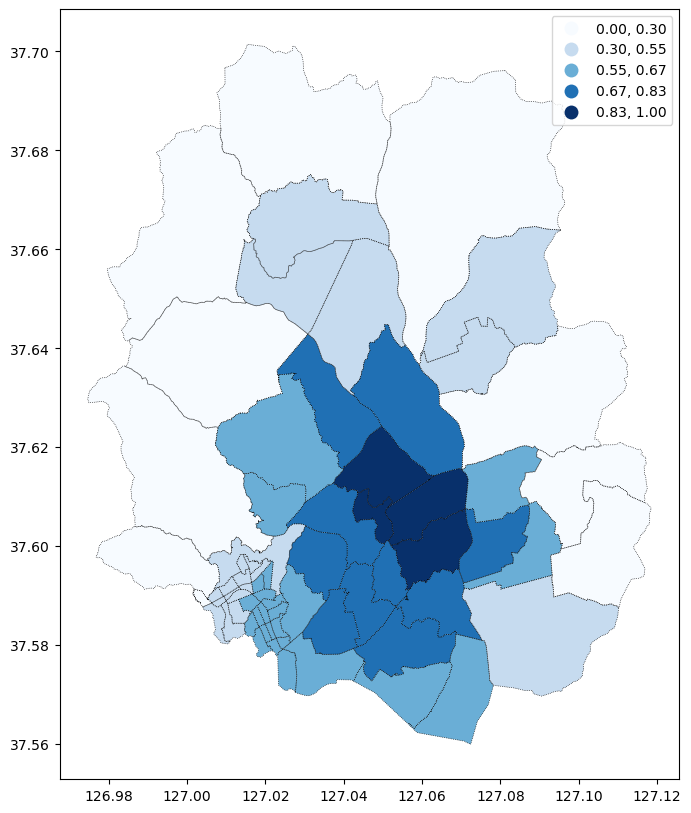

In [55]:

fig, ax = plt.subplots(figsize=(10,10))

demand_nor.plot('sum_normalized', ax=ax, figsize=(10,10), legend=True, cmap='Blues', scheme='FisherJenks')
demand_.boundary.plot(ax=ax, linestyle='dotted', lw=0.5, color='black', zorder=1)